# Analisis Perbandingan Ridge Regression, Decision Tree Regression, dan Polynomial Regression untuk Prediksi Gaji Profesional.

# Tahap 1: Data Understanding

## Sumber Dataset
Dataset ini bersumber dari Kaggle: [Job Salary Prediction Dataset](https://www.kaggle.com/datasets/nalisha/job-salary-prediction-dataset). Dataset ini mengumpulkan berbagai informasi profil profesional pekerja dan faktor-faktor yang memengaruhi besaran gaji mereka. Karena target yang diprediksi adalah nilai numerik (gaji), ini merupakan permasalahan *Regression*.

## Deskripsi Fitur/Variabel
Terdapat 10 variabel di dalam dataset ini:
1. **`job_title`** (Kategorik): Posisi atau jabatan pekerjaan (misal: AI Engineer, Data Analyst, Software Engineer).
2. **`experience_years`** (Numerik): Lama pengalaman kerja dalam hitungan tahun.
3. **`education_level`** (Kategorik): Tingkat pendidikan terakhir (misal: High School, Diploma, Bachelor, Master, PhD).
4. **`skills_count`** (Numerik): Jumlah keahlian/skill yang dikuasai.
5. **`industry`** (Kategorik): Sektor industri tempat bekerja (misal: Healthcare, Telecom, Finance).
6. **`company_size`** (Kategorik): Skala ukuran perusahaan (misal: Startup, Small, Medium, Large, Enterprise).
7. **`location`** (Kategorik): Negara tempat bekerja.
8. **`remote_work`** (Kategorik): Status kerja jarak jauh (misal: Yes, No, Hybrid).
9. **`certifications`** (Numerik): Jumlah sertifikasi profesional yang dimiliki.
10. **`salary`** (Numerik): Gaji yang diterima, yang akan menjadi variabel target untuk diprediksi.

In [ ]:
import pandas as pd

# 1. Membaca Dataset
df = pd.read_csv('job_salary_prediction_dataset.csv')

# 2. Menampilkan 5 baris pertama dataset
print("--- 5 Baris Pertama Dataset ---")
display(df.head())

# 3. Menampilkan informasi umum (tipe data tiap kolom dan pengecekan missing value awal)
print("\n--- Informasi Dataset ---")
display(df.info())

# 4. Menampilkan statistik deskriptif untuk kolom numerik (experience_years, skills_count, certifications, salary)
print("\n--- Statistik Deskriptif (Numerik) ---")
display(df.describe())

# 5. Menampilkan statistik deskriptif untuk kolom kategorik (tipe object)
print("\n--- Statistik Deskriptif (Kategorik) ---")
display(df.describe(include=['object']))

--- 5 Baris Pertama Dataset ---


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413.0
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764.0
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123.0
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123.0
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069.0



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91796 entries, 0 to 91795
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   job_title         91796 non-null  object 
 1   experience_years  91796 non-null  int64  
 2   education_level   91796 non-null  object 
 3   skills_count      91796 non-null  int64  
 4   industry          91796 non-null  object 
 5   company_size      91796 non-null  object 
 6   location          91796 non-null  object 
 7   remote_work       91796 non-null  object 
 8   certifications    91796 non-null  int64  
 9   salary            91795 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 7.0+ MB


None


--- Statistik Deskriptif (Numerik) ---


,experience_years,skills_count,certifications,salary
count,91796.000000,91796.000000,91796.000000,91795.000000
mean,10.004978,9.985032,2.487113,145587.152350
std,6.059022,5.472547,1.709815,37358.477513
min,0.000000,1.000000,0.000000,38779.000000
25%,5.000000,5.000000,1.000000,119334.500000
50%,10.000000,10.000000,2.000000,143303.000000
75%,15.000000,15.000000,4.000000,169324.500000
max,20.000000,19.000000,5.000000,324583.000000



--- Statistik Deskriptif (Kategorik) ---


,job_title,education_level,industry,company_size,location,remote_work
count,91796,91796,91796,91796,91796,91796
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Medium,Sweden,Hybrid
freq,7791,18491,9293,18494,9333,30791


# Data Preprocessing


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Mengatasi Missing Values
print("Missing values sebelum drop:")
print(df.isnull().sum())
df_clean = df.dropna().copy() # Menghapus baris yang memiliki missing values

# 2. Mengatasi Duplikat
jumlah_duplikat = df_clean.duplicated().sum()
print(f"\nJumlah data duplikat yang dihapus: {jumlah_duplikat}")
df_clean.drop_duplicates(inplace=True)

# 3. Menghapus Outlier (Fokus pada kolom target 'salary' menggunakan IQR)
Q1 = df_clean['salary'].quantile(0.25)
Q3 = df_clean['salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data yang berada di dalam batas wajar
df_clean = df_clean[(df_clean['salary'] >= lower_bound) & (df_clean['salary'] <= upper_bound)].copy()
print(f"Sisa baris setelah menghapus outlier: {df_clean.shape[0]} baris")

# 4. Encoding Data Kategorikal
# Ordinal encoding untuk pendidikan
edu_mapping = {'High School': 1, 'Diploma': 2, 'Bachelor': 3, 'Master': 4, 'PhD': 5}
df_clean['education_level'] = df_clean['education_level'].map(edu_mapping)

# One-Hot Encoding untuk kolom kategorik lainnya
kategori_kolom = ['job_title', 'industry', 'company_size', 'location', 'remote_work']
df_encoded = pd.get_dummies(df_clean, columns=kategori_kolom, drop_first=True, dtype=int)

# 5. Standarisasi Data Numerik
scaler = StandardScaler()
kolom_numerik = ['experience_years', 'skills_count', 'certifications']

# Fit dan transform khusus untuk kolom numerik (target 'salary' tidak di-scale)
df_encoded[kolom_numerik] = scaler.fit_transform(df_encoded[kolom_numerik])

print("\n--- 5 Baris Pertama Data Setelah Preprocessing ---")
display(df_encoded.head())
print(f"Bentuk data siap latih: {df_encoded.shape}")

Missing values sebelum drop:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              1
dtype: int64

Jumlah data duplikat yang dihapus: 0
Sisa baris setelah menghapus outlier: 90937 baris

--- 5 Baris Pertama Data Setelah Preprocessing ---


,experience_years,education_level,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,0.008798,3,-1.456072,-0.283297,109413.0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,-0.818226,3,1.285247,-1.453136,93764.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,1.332037,5,-1.090563,-0.868217,148123.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,1.497442,5,0.554228,-1.453136,189123.0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0.835822,3,-0.542299,-1.453136,165069.0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


Bentuk data siap latih: (90937, 40)


# Exploratory Data Analysis (EDA)

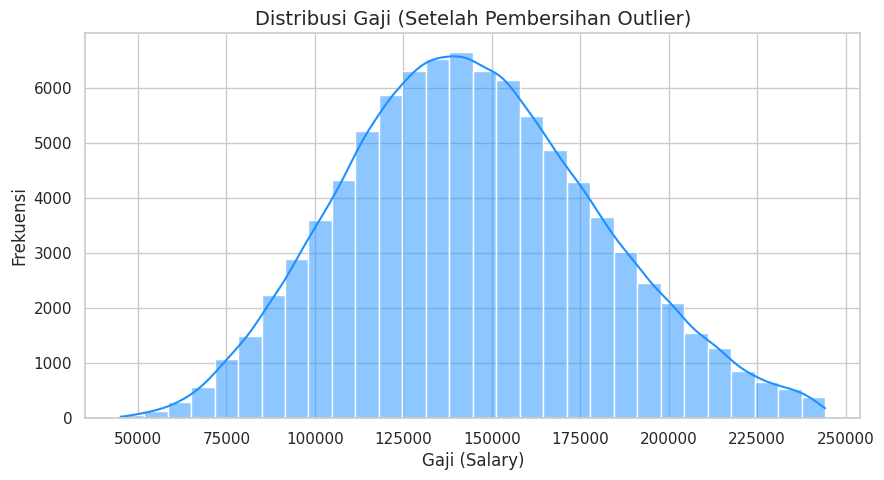

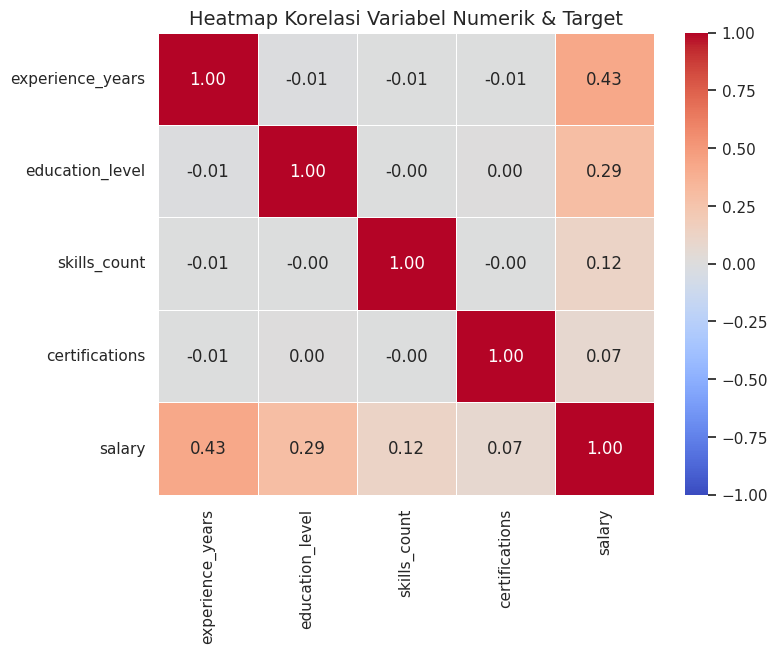

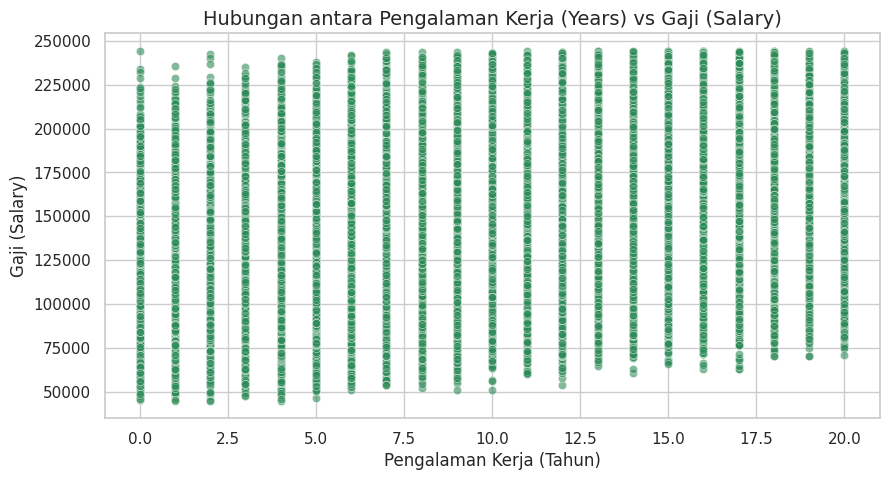

--- INSIGHT SINGKAT ---
1. Dari histogram, Anda bisa melihat apakah gaji terdistribusi normal atau condong ke satu sisi (skewed).
2. Dari heatmap, cari variabel dengan nilai korelasi tertinggi (mendekati 1) terhadap 'salary'. Itu adalah variabel yang paling memengaruhi model regresi nanti.
3. Dari scatter plot, kita bisa melihat pola tren kenaikan gaji seiring bertambahnya tahun pengalaman.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visualisasi
sns.set_theme(style="whitegrid")

# 1. Distribusi Data (Target: Salary)
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['salary'], kde=True, color='dodgerblue', bins=30)
plt.title('Distribusi Gaji (Setelah Pembersihan Outlier)', fontsize=14)
plt.xlabel('Gaji (Salary)')
plt.ylabel('Frekuensi')
plt.show()

# 2. Korelasi Antar Variabel (Fokus pada fitur numerik dan ordinal)
plt.figure(figsize=(8, 6))
# Kita ambil dari df_clean kolom numerik dasar untuk melihat korelasi murninya
kolom_korelasi = ['experience_years', 'education_level', 'skills_count', 'certifications', 'salary']
korelasi = df_clean[kolom_korelasi].corr()

# Membuat Heatmap
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Variabel Numerik & Target', fontsize=14)
plt.show()

# 3. Insight: Hubungan Pengalaman Kerja dan Gaji
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x='experience_years', y='salary', alpha=0.6, color='seagreen')
plt.title('Hubungan antara Pengalaman Kerja (Years) vs Gaji (Salary)', fontsize=14)
plt.xlabel('Pengalaman Kerja (Tahun)')
plt.ylabel('Gaji (Salary)')
plt.show()

# Insight Singkat yang dicetak ke layar
print("--- INSIGHT SINGKAT ---")
print("1. Dari histogram, Anda bisa melihat apakah gaji terdistribusi normal atau condong ke satu sisi (skewed).")
print("2. Dari heatmap, cari variabel dengan nilai korelasi tertinggi (mendekati 1) terhadap 'salary'. Itu adalah variabel yang paling memengaruhi model regresi nanti.")
print("3. Dari scatter plot, kita bisa melihat pola tren kenaikan gaji seiring bertambahnya tahun pengalaman.")

# Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Memisahkan Fitur (X) dan Target (y)
# Target kita adalah 'salary', sehingga kolom ini kita pisahkan dari X
X = df_encoded.drop(columns=['salary'])
y = df_encoded['salary']

print(f"Total baris keseluruhan dataset: {len(df_encoded)}\n")

# 2. Skenario 1: 70% Training : 30% Testing
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.30, random_state=42)
print("--- Skenario 1 (70% Train : 30% Test) ---")
print(f"Data Training : {X_train_70.shape[0]} baris")
print(f"Data Testing  : {X_test_70.shape[0]} baris\n")

# 3. Skenario 2: 80% Training : 20% Testing
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.20, random_state=42)
print("--- Skenario 2 (80% Train : 20% Test) ---")
print(f"Data Training : {X_train_80.shape[0]} baris")
print(f"Data Testing  : {X_test_80.shape[0]} baris\n")

# 4. Skenario 3: 90% Training : 10% Testing
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(X, y, test_size=0.10, random_state=42)
print("--- Skenario 3 (90% Train : 10% Test) ---")
print(f"Data Training : {X_train_90.shape[0]} baris")
print(f"Data Testing  : {X_test_90.shape[0]} baris")

Total baris keseluruhan dataset: 90937

--- Skenario 1 (70% Train : 30% Test) ---
Data Training : 63655 baris
Data Testing  : 27282 baris

--- Skenario 2 (80% Train : 20% Test) ---
Data Training : 72749 baris
Data Testing  : 18188 baris

--- Skenario 3 (90% Train : 10% Test) ---
Data Training : 81843 baris
Data Testing  : 9094 baris


# Model Building dan Hyperparameter Tuning (80:20)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures

# Kita sepakati menggunakan data 80:20 untuk tahapan ini
X_train = X_train_80
y_train = y_train_80
X_test = X_test_80
y_test = y_test_80

print("=============================================")
print("          TAHAP 5: MODEL BUILDING            ")
print("=============================================\n")

# 1. Ridge Regression (Base Model dengan alpha default = 1.0)
ridge_base = Ridge(alpha=1.0, random_state=42)
ridge_base.fit(X_train, y_train)
print("[✓] Ridge Regression berhasil dilatih.")

# 2. Decision Tree Regression (Base Model)
dt_base = DecisionTreeRegressor(max_depth=15, random_state=42)
dt_base.fit(X_train, y_train)
print("[✓] Decision Tree Regression berhasil dilatih.")

# 3. Polynomial Regression (Degree = 2 digabung dengan Ridge Regression)
poly_feat_base = PolynomialFeatures(degree=2)
X_train_poly = poly_feat_base.fit_transform(X_train)
poly_base = Ridge(alpha=1.0, random_state=42) # Menggunakan Ridge di dalam Polynomial
poly_base.fit(X_train_poly, y_train)
print("[✓] Polynomial Regression berhasil dilatih.\n")


print("=============================================")
print("   TAHAP 6: HYPERPARAMETER TUNING (MANUAL)   ")
print("=============================================\n")

# A. Tuning Ridge Regression (Fokus pada alpha)
print("--- A. Hasil Tuning Ridge Regression (Parameter: alpha) ---")
alpha_list = [0.1, 1.0, 10.0, 100.0, 500.0]

for a in alpha_list:
    ridge_tune = Ridge(alpha=a, random_state=42)
    ridge_tune.fit(X_train, y_train)
    skor_ridge_r2 = ridge_tune.score(X_test, y_test)
    print(f"Model dengan alpha     = {str(a).ljust(5)} -> R2 Score: {skor_ridge_r2:.4f}")

# B. Tuning Decision Tree (Fokus pada max_depth)
print("\n--- B. Hasil Tuning Decision Tree (Parameter: max_depth) ---")
kedalaman_list = [3, 5, 10, 15, None]

for d in kedalaman_list:
    dt_tune = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_tune.fit(X_train, y_train)
    skor_dt_r2 = dt_tune.score(X_test, y_test)
    print(f"Model dengan max_depth = {str(d).ljust(5)} -> R2 Score: {skor_dt_r2:.4f}")

# C. Tuning Polynomial Regression (Fokus pada degree)
print("\n--- C. Hasil Tuning Polynomial Regression (Parameter: degree) ---")
derajat_list = [1, 2]

for deg in derajat_list:
    poly_tune = PolynomialFeatures(degree=deg)
    X_train_p_tune = poly_tune.fit_transform(X_train)
    X_test_p_tune = poly_tune.transform(X_test)

    # Kita tetap konsisten menggunakan Ridge di dalam tuning polynomial-nya
    poly_reg_tune = Ridge(alpha=1.0, random_state=42)
    poly_reg_tune.fit(X_train_p_tune, y_train)
    skor_poly_r2 = poly_reg_tune.score(X_test_p_tune, y_test)
    print(f"Model dengan degree    = {str(deg).ljust(5)} -> R2 Score: {skor_poly_r2:.4f}")

          TAHAP 5: MODEL BUILDING            

[✓] Ridge Regression berhasil dilatih.
[✓] Decision Tree Regression berhasil dilatih.
[✓] Polynomial Regression berhasil dilatih.

   TAHAP 6: HYPERPARAMETER TUNING (MANUAL)   

--- A. Hasil Tuning Ridge Regression (Parameter: alpha) ---
Model dengan alpha     = 0.1   -> R2 Score: 0.9601
Model dengan alpha     = 1.0   -> R2 Score: 0.9601
Model dengan alpha     = 10.0  -> R2 Score: 0.9601
Model dengan alpha     = 100.0 -> R2 Score: 0.9584
Model dengan alpha     = 500.0 -> R2 Score: 0.9420

--- B. Hasil Tuning Decision Tree (Parameter: max_depth) ---
Model dengan max_depth = 3     -> R2 Score: 0.4125
Model dengan max_depth = 5     -> R2 Score: 0.5392
Model dengan max_depth = 10    -> R2 Score: 0.7741
Model dengan max_depth = 15    -> R2 Score: 0.8700
Model dengan max_depth = None  -> R2 Score: 0.8831

--- C. Hasil Tuning Polynomial Regression (Parameter: degree) ---
Model dengan degree    = 1     -> R2 Score: 0.9601
Model dengan degree    = 

# Model Building dan Hyperparameter Tuning (70:30)

In [ ]:
# Menggunakan data 70:30 untuk tahapan ini
X_train = X_train_70
y_train = y_train_70
X_test = X_test_70
y_test = y_test_70

print("=====================================================")
print("  TAHAP 5: MODEL BUILDING (DATA SPLIT 70:30)         ")
print("=====================================================\n")

# 1. Ridge Regression (Base Model)
ridge_base_70 = Ridge(alpha=1.0, random_state=42)
ridge_base_70.fit(X_train, y_train)
print("[✓] Ridge Regression (70:30) berhasil dilatih.")

# 2. Decision Tree Regression (Base Model)
dt_base_70 = DecisionTreeRegressor(max_depth=15, random_state=42)
dt_base_70.fit(X_train, y_train)
print("[✓] Decision Tree Regression (70:30) berhasil dilatih.")

# 3. Polynomial Regression
poly_feat_base_70 = PolynomialFeatures(degree=2)
X_train_poly_70 = poly_feat_base_70.fit_transform(X_train)
poly_base_70 = Ridge(alpha=1.0, random_state=42)
poly_base_70.fit(X_train_poly_70, y_train)
print("[✓] Polynomial Regression (70:30) berhasil dilatih.\n")


print("=====================================================")
print("  TAHAP 6: HYPERPARAMETER TUNING (DATA SPLIT 70:30)  ")
print("=====================================================\n")

# A. Tuning Ridge Regression
print("--- A. Hasil Tuning Ridge Regression ---")
for a in [0.1, 1.0, 10.0, 100.0, 500.0]:
    ridge_tune = Ridge(alpha=a, random_state=42)
    ridge_tune.fit(X_train, y_train)
    skor = ridge_tune.score(X_test, y_test)
    print(f"Model dengan alpha     = {str(a).ljust(5)} -> R2 Score: {skor:.4f}")

# B. Tuning Decision Tree
print("\n--- B. Hasil Tuning Decision Tree ---")
for d in [3, 5, 10, 15, None]:
    dt_tune = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_tune.fit(X_train, y_train)
    skor = dt_tune.score(X_test, y_test)
    print(f"Model dengan max_depth = {str(d).ljust(5)} -> R2 Score: {skor:.4f}")

# C. Tuning Polynomial Regression
print("\n--- C. Hasil Tuning Polynomial Regression ---")
for deg in [1, 2]:
    poly_tune = PolynomialFeatures(degree=deg)
    X_train_p_tune = poly_tune.fit_transform(X_train)
    X_test_p_tune = poly_tune.transform(X_test)

    poly_reg_tune = Ridge(alpha=1.0, random_state=42)
    poly_reg_tune.fit(X_train_p_tune, y_train)
    skor = poly_reg_tune.score(X_test_p_tune, y_test)
    print(f"Model dengan degree    = {str(deg).ljust(5)} -> R2 Score: {skor:.4f}")

  TAHAP 5: MODEL BUILDING (DATA SPLIT 70:30)         

[✓] Ridge Regression (70:30) berhasil dilatih.
[✓] Decision Tree Regression (70:30) berhasil dilatih.
[✓] Polynomial Regression (70:30) berhasil dilatih.

  TAHAP 6: HYPERPARAMETER TUNING (DATA SPLIT 70:30)  

--- A. Hasil Tuning Ridge Regression ---
Model dengan alpha     = 0.1   -> R2 Score: 0.9601
Model dengan alpha     = 1.0   -> R2 Score: 0.9601
Model dengan alpha     = 10.0  -> R2 Score: 0.9601
Model dengan alpha     = 100.0 -> R2 Score: 0.9580
Model dengan alpha     = 500.0 -> R2 Score: 0.9390

--- B. Hasil Tuning Decision Tree ---
Model dengan max_depth = 3     -> R2 Score: 0.4129
Model dengan max_depth = 5     -> R2 Score: 0.5409
Model dengan max_depth = 10    -> R2 Score: 0.7732
Model dengan max_depth = 15    -> R2 Score: 0.8685
Model dengan max_depth = None  -> R2 Score: 0.8744

--- C. Hasil Tuning Polynomial Regression ---
Model dengan degree    = 1     -> R2 Score: 0.9601
Model dengan degree    = 2     -> R2 Score: 0.9

# Model Building dan Hyperparameter Tuning (90:10)

In [ ]:
# Menggunakan data 90:10 untuk tahapan ini
X_train = X_train_90
y_train = y_train_90
X_test = X_test_90
y_test = y_test_90

print("=====================================================")
print("  TAHAP 5: MODEL BUILDING (DATA SPLIT 90:10)         ")
print("=====================================================\n")

# 1. Ridge Regression (Base Model)
ridge_base_90 = Ridge(alpha=1.0, random_state=42)
ridge_base_90.fit(X_train, y_train)
print("[✓] Ridge Regression (90:10) berhasil dilatih.")

# 2. Decision Tree Regression (Base Model)
dt_base_90 = DecisionTreeRegressor(max_depth=15, random_state=42)
dt_base_90.fit(X_train, y_train)
print("[✓] Decision Tree Regression (90:10) berhasil dilatih.")

# 3. Polynomial Regression
poly_feat_base_90 = PolynomialFeatures(degree=2)
X_train_poly_90 = poly_feat_base_90.fit_transform(X_train)
poly_base_90 = Ridge(alpha=1.0, random_state=42)
poly_base_90.fit(X_train_poly_90, y_train)
print("[✓] Polynomial Regression (90:10) berhasil dilatih.\n")


print("=====================================================")
print("  TAHAP 6: HYPERPARAMETER TUNING (DATA SPLIT 90:10)  ")
print("=====================================================\n")

# A. Tuning Ridge Regression
print("--- A. Hasil Tuning Ridge Regression ---")
for a in [0.1, 1.0, 10.0, 100.0, 500.0]:
    ridge_tune = Ridge(alpha=a, random_state=42)
    ridge_tune.fit(X_train, y_train)
    skor = ridge_tune.score(X_test, y_test)
    print(f"Model dengan alpha     = {str(a).ljust(5)} -> R2 Score: {skor:.4f}")

# B. Tuning Decision Tree
print("\n--- B. Hasil Tuning Decision Tree ---")
for d in [3, 5, 10, 15, None]:
    dt_tune = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_tune.fit(X_train, y_train)
    skor = dt_tune.score(X_test, y_test)
    print(f"Model dengan max_depth = {str(d).ljust(5)} -> R2 Score: {skor:.4f}")

# C. Tuning Polynomial Regression
print("\n--- C. Hasil Tuning Polynomial Regression ---")
for deg in [1, 2]:
    poly_tune = PolynomialFeatures(degree=deg)
    X_train_p_tune = poly_tune.fit_transform(X_train)
    X_test_p_tune = poly_tune.transform(X_test)

    poly_reg_tune = Ridge(alpha=1.0, random_state=42)
    poly_reg_tune.fit(X_train_p_tune, y_train)
    skor = poly_reg_tune.score(X_test_p_tune, y_test)
    print(f"Model dengan degree    = {str(deg).ljust(5)} -> R2 Score: {skor:.4f}")

  TAHAP 5: MODEL BUILDING (DATA SPLIT 90:10)         

[✓] Ridge Regression (90:10) berhasil dilatih.
[✓] Decision Tree Regression (90:10) berhasil dilatih.
[✓] Polynomial Regression (90:10) berhasil dilatih.

  TAHAP 6: HYPERPARAMETER TUNING (DATA SPLIT 90:10)  

--- A. Hasil Tuning Ridge Regression ---
Model dengan alpha     = 0.1   -> R2 Score: 0.9603
Model dengan alpha     = 1.0   -> R2 Score: 0.9603
Model dengan alpha     = 10.0  -> R2 Score: 0.9603
Model dengan alpha     = 100.0 -> R2 Score: 0.9589
Model dengan alpha     = 500.0 -> R2 Score: 0.9446

--- B. Hasil Tuning Decision Tree ---
Model dengan max_depth = 3     -> R2 Score: 0.4101
Model dengan max_depth = 5     -> R2 Score: 0.5347
Model dengan max_depth = 10    -> R2 Score: 0.7736
Model dengan max_depth = 15    -> R2 Score: 0.8738
Model dengan max_depth = None  -> R2 Score: 0.8872

--- C. Hasil Tuning Polynomial Regression ---
Model dengan degree    = 1     -> R2 Score: 0.9603
Model dengan degree    = 2     -> R2 Score: 0.9

# Model Evaluation

          TABEL KESIMPULAN EVALUASI MODEL                



,Rasio Data,Algoritma,R2 Score,MAE,RMSE
0,70% Train : 30% Test,Ridge Regression,0.960077,5551.737425,7145.756707
1,70% Train : 30% Test,Decision Tree,0.868545,10132.503266,12966.671436
2,70% Train : 30% Test,Polynomial Regression,0.979925,4041.437148,5067.165531
3,80% Train : 20% Test,Ridge Regression,0.960107,5561.188093,7144.349523
4,80% Train : 20% Test,Decision Tree,0.870009,10062.129130,12896.517170
5,80% Train : 20% Test,Polynomial Regression,0.979851,4052.569286,5077.447610
6,90% Train : 10% Test,Ridge Regression,0.960341,5547.568906,7116.588502
7,90% Train : 10% Test,Decision Tree,0.873832,9922.360727,12693.300084
8,90% Train : 10% Test,Polynomial Regression,0.980220,4013.752764,5025.873277


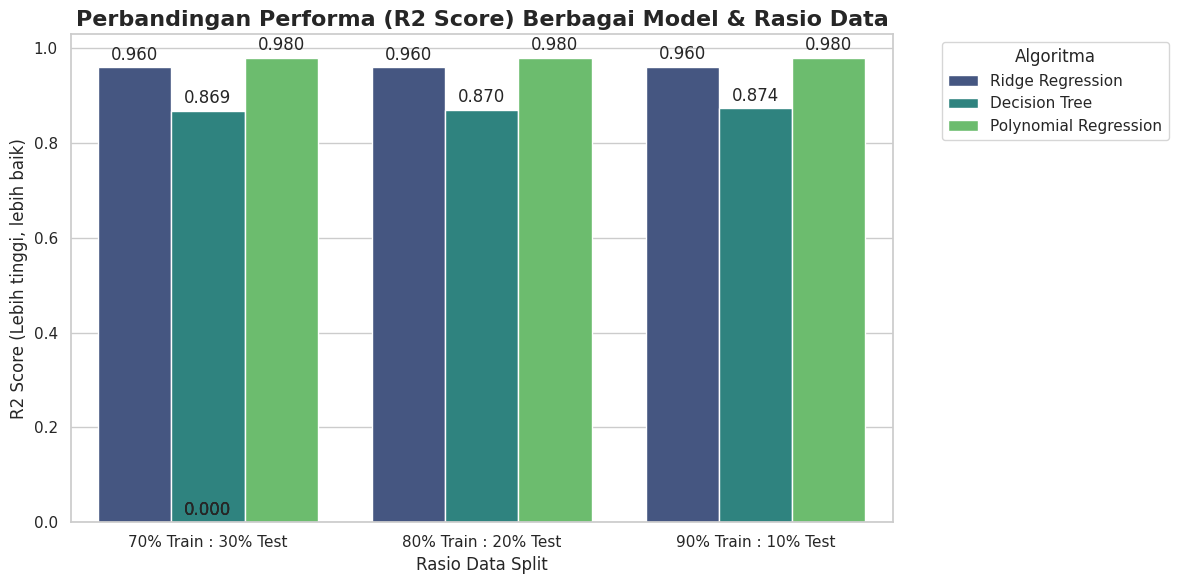

In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures

# 1. Mengumpulkan semua variasi split data ke dalam dictionary
data_splits = {
    "70% Train : 30% Test": (X_train_70, X_test_70, y_train_70, y_test_70),
    "80% Train : 20% Test": (X_train_80, X_test_80, y_train_80, y_test_80),
    "90% Train : 10% Test": (X_train_90, X_test_90, y_train_90, y_test_90)
}

hasil_evaluasi = []

# 2. Melakukan looping untuk setiap variasi split dan melatih ulang model terbaik
for split_name, (X_tr, X_te, y_tr, y_te) in data_splits.items():

    # --- A. Ridge Regression ---
    ridge = Ridge(alpha=1.0, random_state=42)
    ridge.fit(X_tr, y_tr)
    pred_ridge = ridge.predict(X_te)

    hasil_evaluasi.append({
        "Rasio Data": split_name,
        "Algoritma": "Ridge Regression",
        "R2 Score": r2_score(y_te, pred_ridge),
        "MAE": mean_absolute_error(y_te, pred_ridge),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred_ridge))
    })

    # --- B. Decision Tree ---
    # Menggunakan max_depth=10 sebagai perwakilan parameter yang seimbang
    dt = DecisionTreeRegressor(max_depth=15, random_state=42)
    dt.fit(X_tr, y_tr)
    pred_dt = dt.predict(X_te)

    hasil_evaluasi.append({
        "Rasio Data": split_name,
        "Algoritma": "Decision Tree",
        "R2 Score": r2_score(y_te, pred_dt),
        "MAE": mean_absolute_error(y_te, pred_dt),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred_dt))
    })

    # --- C. Polynomial Regression ---
    poly = PolynomialFeatures(degree=2)
    X_tr_poly = poly.fit_transform(X_tr)
    X_te_poly = poly.transform(X_te) # Transform test data juga!

    poly_ridge = Ridge(alpha=1.0, random_state=42)
    poly_ridge.fit(X_tr_poly, y_tr)
    pred_poly = poly_ridge.predict(X_te_poly)

    hasil_evaluasi.append({
        "Rasio Data": split_name,
        "Algoritma": "Polynomial Regression",
        "R2 Score": r2_score(y_te, pred_poly),
        "MAE": mean_absolute_error(y_te, pred_poly),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred_poly))
    })

# 3. Menjadikan Hasil sebagai DataFrame agar mudah dibaca
df_eval = pd.DataFrame(hasil_evaluasi)

print("=========================================================")
print("          TABEL KESIMPULAN EVALUASI MODEL                ")
print("=========================================================\n")
display(df_eval)

# 4. Membuat Visualisasi Bar Chart untuk R2 Score
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
grafik = sns.barplot(data=df_eval, x='Rasio Data', y='R2 Score', hue='Algoritma', palette='viridis')

# Menambahkan keterangan angka di atas bar
for p in grafik.patches:
    grafik.annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.title('Perbandingan Performa (R2 Score) Berbagai Model & Rasio Data', fontsize=16, fontweight='bold')
plt.xlabel('Rasio Data Split', fontsize=12)
plt.ylabel('R2 Score (Lebih tinggi, lebih baik)', fontsize=12)
plt.legend(title='Algoritma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Model Comparison

    1. TABEL PERBANDINGAN PERFORMA (PIVOT TABLE)         



R2 Score                       \
Rasio Data            70% Train : 30% Test 80% Train : 20% Test   
Algoritma                                                         
Decision Tree                     0.868545             0.870009   
Polynomial Regression             0.979925             0.979851   
Ridge Regression                  0.960077             0.960107   

                                                            MAE  \
Rasio Data            90% Train : 10% Test 70% Train : 30% Test   
Algoritma                                                         
Decision Tree                     0.873832         10132.503266   
Polynomial Regression             0.980220          4041.437148   
Ridge Regression                  0.960341          5551.737425   

                                                                 \
Rasio Data            80% Train : 20% Test 90% Train : 10% Test   
Algoritma                                                         
Decision Tree                 10062.129130          9922.360727   
Polynomial Regression          4052.569286          4013.752764   
Ridge Regression               5561.188093          5547.568906   

                                      RMSE                       \
Rasio Data            70% Train : 30% Test 80% Train : 20% Test   
Algoritma                                                         
Decision Tree                 12966.671436         12896.517170   
Polynomial Regression          5067.165531          5077.447610   
Ridge Regression               7145.756707          7144.349523   

                                            
Rasio Data            90% Train : 10% Test  
Algoritma                                   
Decision Tree                 12693.300084  
Polynomial Regression          5025.873277  
Ridge Regression               7116.588502

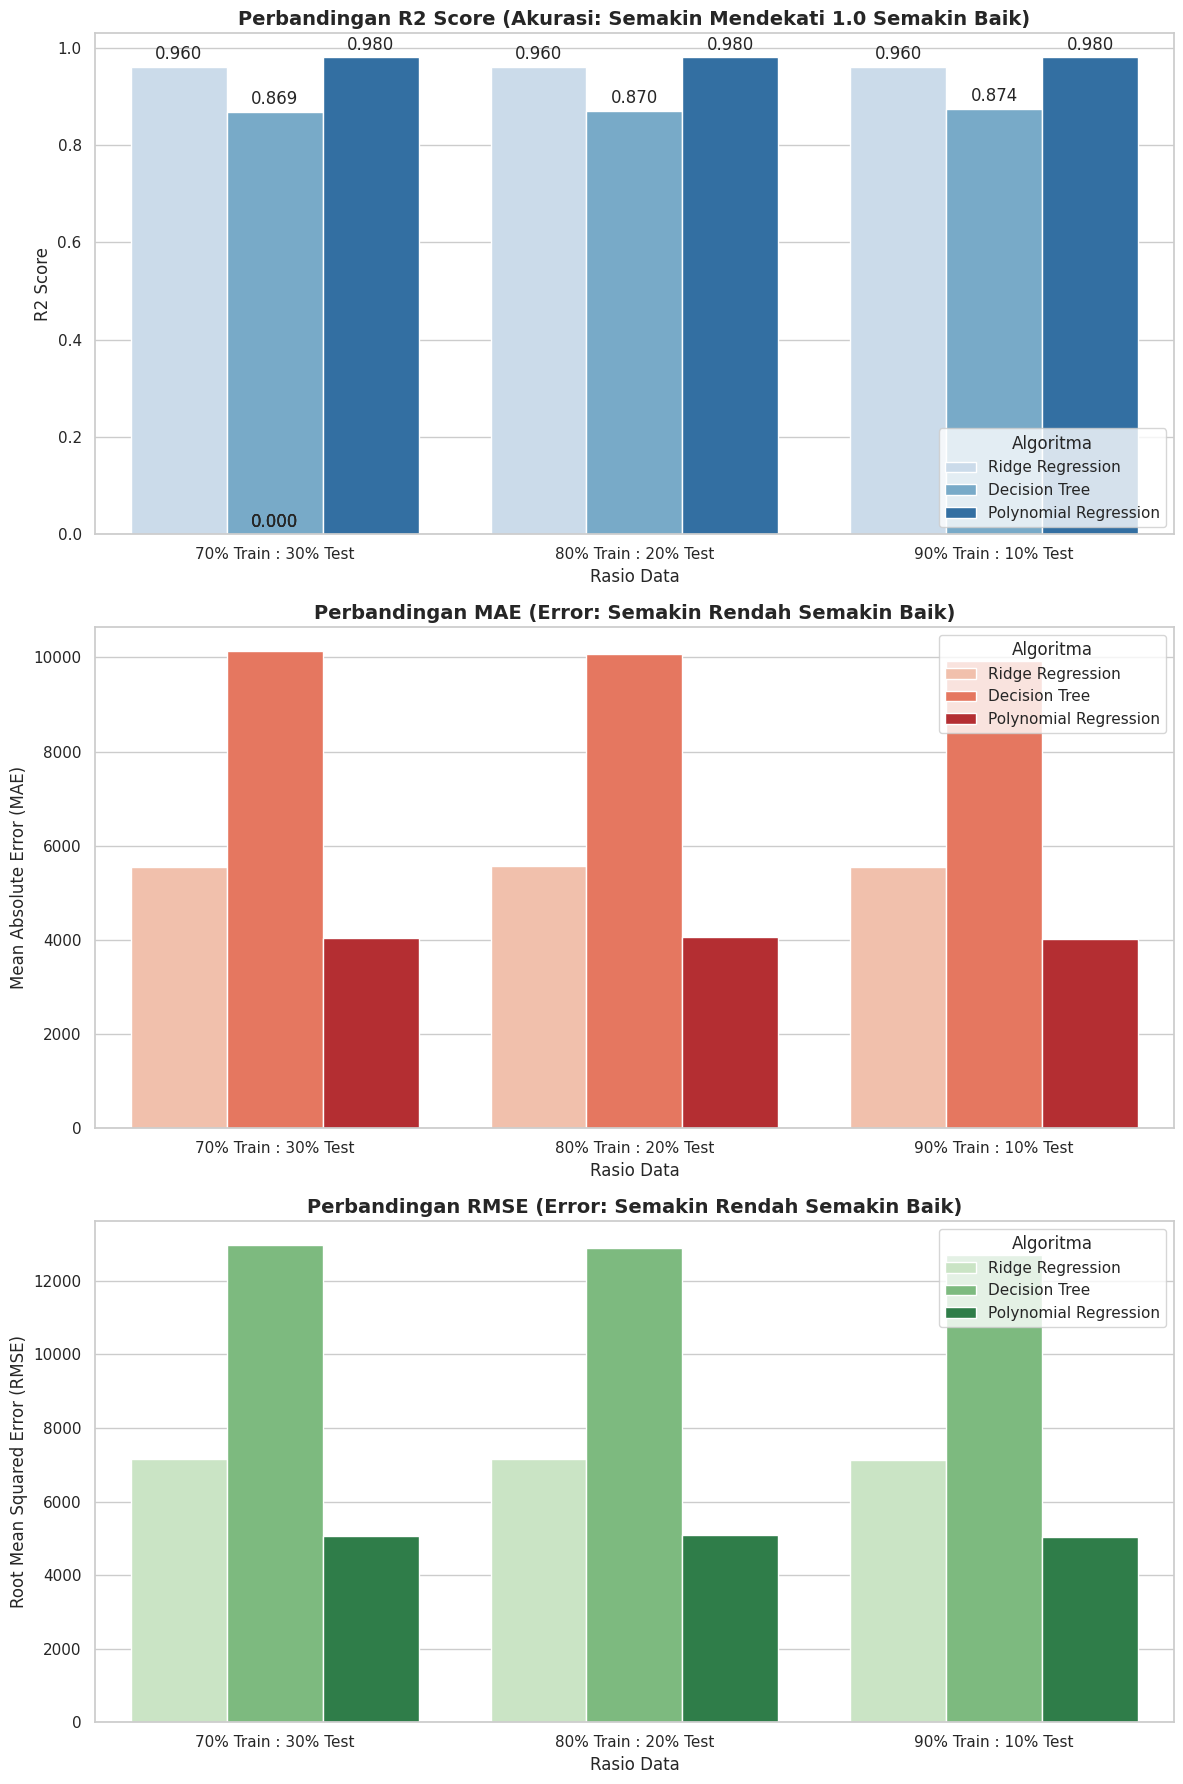

                 KESIMPULAN MODEL TERBAIK                
Berdasarkan hasil komparasi, model dengan performa paling optimal adalah:

🏆 Algoritma   : Polynomial Regression
📊 Rasio Data  : 90% Train : 10% Test
🎯 R2 Score    : 0.9802
📉 MAE         : 4,013.75
📉 RMSE        : 5,025.87

Model inilah yang paling direkomendasikan untuk memprediksi gaji berdasarkan dataset ini.


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=========================================================")
print("    1. TABEL PERBANDINGAN PERFORMA (PIVOT TABLE)         ")
print("=========================================================\n")
# Membuat Pivot table agar perbandingan lebih elegan
pivot_eval = df_eval.pivot(index='Algoritma', columns='Rasio Data', values=['R2 Score', 'MAE', 'RMSE'])
display(pivot_eval)


# Membuat canvas untuk 3 grafik (R2, MAE, RMSE) disusun ke bawah
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
sns.set_theme(style="whitegrid")

# Grafik 1: R2 Score (Akurasi Regression) - Makin tinggi makin baik
sns.barplot(data=df_eval, x='Rasio Data', y='R2 Score', hue='Algoritma', palette='Blues', ax=axes[0])
axes[0].set_title('Perbandingan R2 Score (Akurasi: Semakin Mendekati 1.0 Semakin Baik)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R2 Score')
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

# Grafik 2: MAE (Rata-rata Error) - Makin rendah makin baik
sns.barplot(data=df_eval, x='Rasio Data', y='MAE', hue='Algoritma', palette='Reds', ax=axes[1])
axes[1].set_title('Perbandingan MAE (Error: Semakin Rendah Semakin Baik)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (MAE)')

# Grafik 3: RMSE - Makin rendah makin baik
sns.barplot(data=df_eval, x='Rasio Data', y='RMSE', hue='Algoritma', palette='Greens', ax=axes[2])
axes[2].set_title('Perbandingan RMSE (Error: Semakin Rendah Semakin Baik)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Root Mean Squared Error (RMSE)')

plt.tight_layout()
plt.show()

# Kesimpulan Otomatis (Mencari R2 tertinggi)
best_model = df_eval.loc[df_eval['R2 Score'].idxmax()]

print("=========================================================")
print("                 KESIMPULAN MODEL TERBAIK                ")
print("=========================================================")
print(f"Berdasarkan hasil komparasi, model dengan performa paling optimal adalah:\n")
print(f"🏆 Algoritma   : {best_model['Algoritma']}")
print(f"📊 Rasio Data  : {best_model['Rasio Data']}")
print(f"🎯 R2 Score    : {best_model['R2 Score']:.4f}")
print(f"📉 MAE         : {best_model['MAE']:,.2f}")
print(f"📉 RMSE        : {best_model['RMSE']:,.2f}")
print("\nModel inilah yang paling direkomendasikan untuk memprediksi gaji berdasarkan dataset ini.")
print("=========================================================")

In [ ]:
import pickle

# Train semua model
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X, y)

dt = DecisionTreeRegressor(max_depth=15, random_state=42)
dt.fit(X, y)

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = Ridge(alpha=1.0, random_state=42)
poly_model.fit(X_poly, y)

# Simpan semua
pickle.dump(ridge, open('ridge.pkl', 'wb'))
pickle.dump(dt, open('dt.pkl', 'wb'))
pickle.dump(poly_model, open('poly.pkl', 'wb'))
pickle.dump(poly, open('poly_transform.pkl', 'wb'))

# Kolom
pickle.dump(X.columns, open('columns.pkl', 'wb'))